In [ ]:
#
# Project:
#      PyTorch Dojo (https://github.com/wo3kie/ml-dojo)
#
# Author:
#      Lukasz Czerwinski (https://www.lukaszczerwinski.pl/)
#

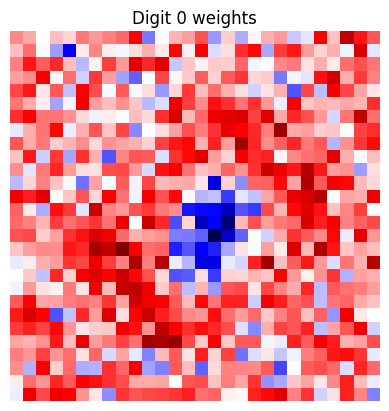

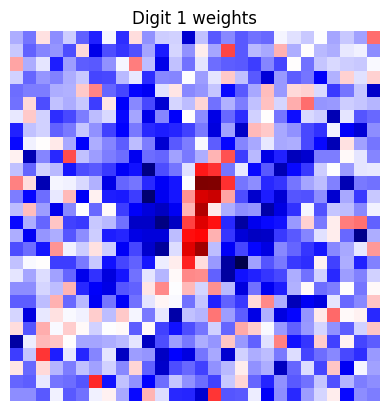

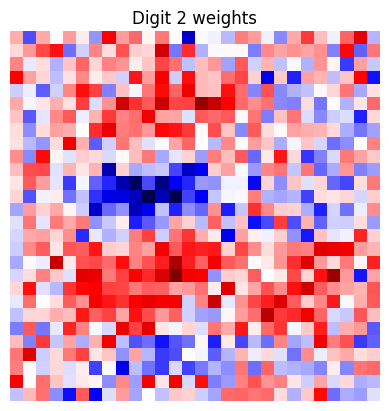

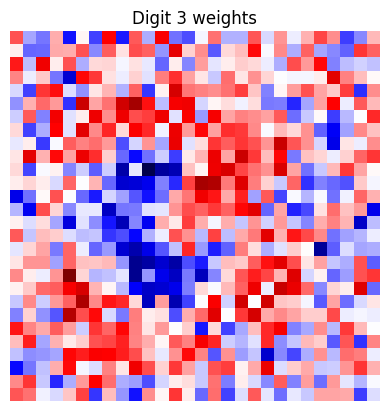

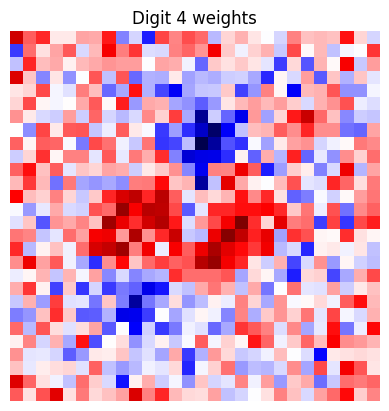

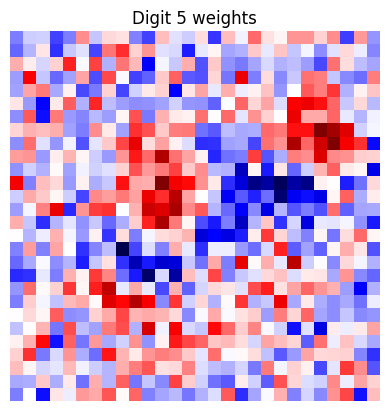

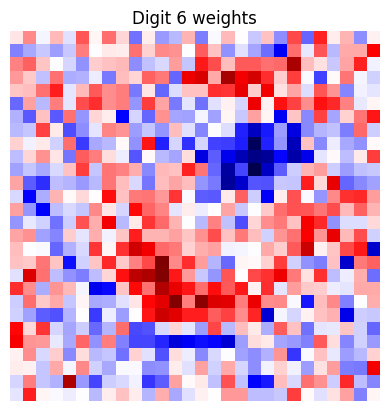

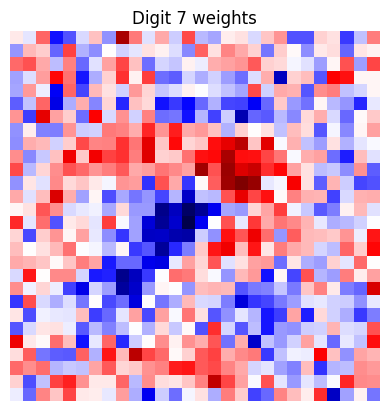

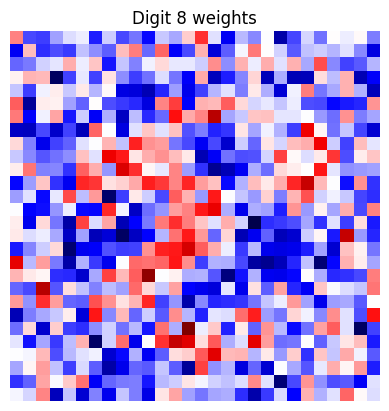

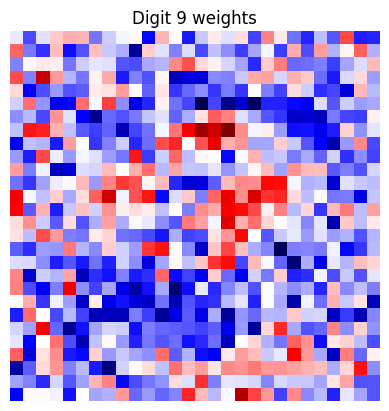

None


In [ ]:
import torch
from torchvision import datasets, transforms

import import_ipynb
from common import assert_eq # type: ignore
from log_reg_NC_sgd_gradient import logistic_regression_nc_sgd_gradient as logistic_regression_nc # type: ignore

from matplotlib import pyplot as plt

def show_mnist_weights(s: int, epochs: int, lr=0.1) -> float:
  to_tensor = transforms.ToTensor()

  train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=to_tensor)
  test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=to_tensor)

  samples_train = train_dataset.data[:s].float() / 255.0
  samples_train = torch.reshape(samples_train, (samples_train.shape[0], -1))
  labels_train = train_dataset.targets[:s]
  labels_train = torch.reshape(labels_train, (-1, 1))

  (_, model_W, _) = logistic_regression_nc(samples_train, labels_train, epochs=epochs, lr=lr)
  assert_eq(model_W.T.shape, (10, 28*28))

  # Show the weights as images.
  for i in range(10):
    weights = model_W.T[i].reshape(28, 28)

    plt.imshow(weights, cmap='gray')
    plt.title(f"Digit {i} weights")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    #
    # May take a while to run, but should be above 90% accuracy.
    #

    print(show_mnist_weights(s=10000, epochs=1000, lr=0.1))
 